# AICG-CaST publication figures and tables

This notebook is the end-to-end results pipeline for the AICG-CaST package.
It runs the unit test suite, generates a synthetic cohort, trains baseline
classifiers, fits a Mechanism-Bottleneck Causal Network (MB-CNet), scores a
small AICG-Bench sweep, computes survival outcomes, renders the theory
graph, and exercises the validation helpers.

All figures are saved as **PNG (300 dpi)** and **PDF** under
`outputs/notebook/figures/`. All tables are saved as **CSV** under
`outputs/notebook/tables/`. A manifest of generated artefacts is written at
the end.

> The package is synthetic by design. Results below are *not* clinical,
> regulatory, or epidemiological claims. See `docs/ethics_and_limitations.md`.

Run cells top-to-bottom. Expected wall-clock on a laptop is roughly 30–90 s
depending on test suite latency.

In [2]:
# --- setup ----------------------------------------------------------------
from __future__ import annotations

import json
import os
import sys
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure the src/ layout is importable when the notebook is launched from
# anywhere in the repo.
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "src" / "icg_cast").exists() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

OUTDIR = REPO_ROOT / "outputs" / "notebook"
FIGDIR = OUTDIR / "figures"
TABDIR = OUTDIR / "tables"
for d in (FIGDIR, TABDIR):
    d.mkdir(parents=True, exist_ok=True)

# Publication-style matplotlib defaults.
mpl.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.transparent": False,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "pdf.fonttype": 42,   # editable text in PDF
    "ps.fonttype": 42,
})

PALETTE = {
    "baseline": "#4E79A7",
    "mb_cnet":  "#E15759",
    "good":     "#59A14F",
    "bad":      "#B07AA1",
    "neutral":  "#888888",
}

def save(fig, name: str) -> tuple[Path, Path]:
    png = FIGDIR / f"{name}.png"
    pdf = FIGDIR / f"{name}.pdf"
    fig.savefig(png)
    fig.savefig(pdf)
    return png, pdf

def save_table(df: pd.DataFrame, name: str) -> Path:
    path = TABDIR / f"{name}.csv"
    df.to_csv(path, index=False)
    return path

warnings.filterwarnings("ignore", category=UserWarning)
print(f"repo root: {REPO_ROOT}")
print(f"outputs:   {OUTDIR}")

repo root: /Users/julhashkazi/Desktop/aicg_build_plan_with_starter_kit
outputs:   /Users/julhashkazi/Desktop/aicg_build_plan_with_starter_kit/outputs/notebook


## 1. Run the unit test suite

We invoke pytest as a subprocess so the notebook still runs even if the
package's tests share state with the surrounding Jupyter kernel.

In [3]:
import subprocess

env = os.environ.copy()
env["PYTHONPATH"] = str(SRC)

result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests", "-q", "--no-header"],
    cwd=REPO_ROOT,
    env=env,
    capture_output=True,
    text=True,
)
print(result.stdout[-1500:])
if result.returncode != 0:
    print("--- stderr (tail) ---")
    print(result.stderr[-1500:])

assert result.returncode == 0, "pytest failed; see output above"

import re

_ANSI_RE = re.compile(r"\x1b\[[0-9;]*m")
# Persist the test summary line for the manifest (strip ANSI colour codes).
TEST_SUMMARY = _ANSI_RE.sub(
    "",
    next(
        (line for line in reversed(result.stdout.splitlines()) if "passed" in line or "failed" in line),
        "test output unavailable",
    ),
).strip()
print()
print("PASS:", TEST_SUMMARY)

.....................................................................    [100%]
69 passed in 16.82s


PASS: 69 passed in 16.82s


## 2. Simulate a synthetic cohort

A small cohort (`n = 400`, `months = 24`, `seed = 7`) is enough to drive
every downstream figure while keeping the notebook fast. The simulator's
default 8 archetypes and 10 qAOP states are used unchanged.

In [4]:
from icg_cast import SimConfig, simulate_cohort

CFG = SimConfig(n=400, months=24, seed=7)
cohort, trajectories = simulate_cohort(CFG)
save_table(cohort, "cohort")

archetype_summary = (
    cohort.groupby("chemical_archetype")
    .agg(
        n=("sample_id", "count"),
        event_rate=("future_cancer_transition_event", "mean"),
        mean_final_risk=("state_final_latent_risk", "mean"),
        mean_dose=("dose", "mean"),
    )
    .sort_values("mean_final_risk")
    .reset_index()
)
save_table(archetype_summary, "archetype_summary")
archetype_summary

,chemical_archetype,n,event_rate,mean_final_risk,mean_dose
0,inert_control,59,0.000000,0.000755,1.185470
1,metal_epigenetic_like,44,0.000000,0.023691,1.068340
2,immune_suppression_like,46,0.021739,0.024450,0.930203
3,endocrine_receptor_like,51,0.019608,0.029825,1.066509
4,cyp2e1_ros_like,53,0.037736,0.081575,1.170809
5,aristolochic_like,46,0.000000,0.085831,1.406548
6,aflatoxin_like,53,0.113208,0.106379,1.351432
7,pah_tobacco_like,48,0.020833,0.125654,1.309949


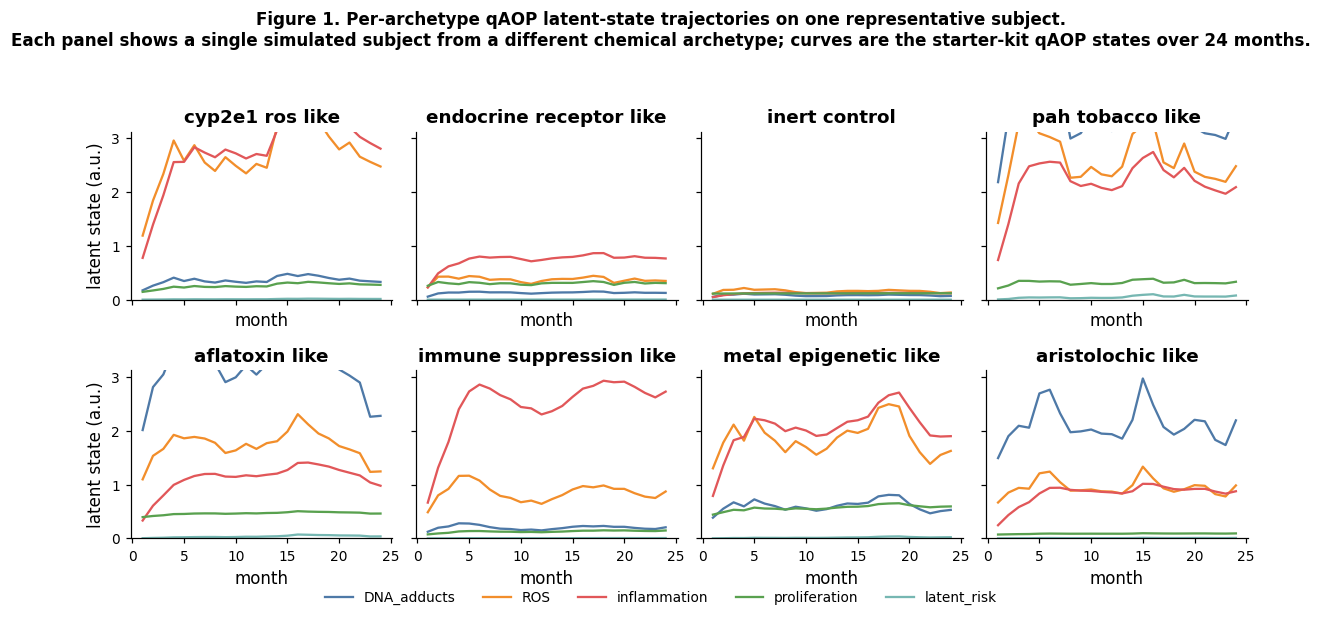

In [5]:
# Figure 1: example state trajectories for one representative subject per
# archetype.
fig, axes = plt.subplots(2, 4, figsize=(11, 5.2), sharex=True, sharey=True)
axes = axes.ravel()
state_cols = ["DNA_adducts", "ROS", "inflammation", "proliferation", "latent_risk"]
state_colors = {
    "DNA_adducts":  "#4E79A7",
    "ROS":          "#F28E2B",
    "inflammation": "#E15759",
    "proliferation":"#59A14F",
    "latent_risk":  "#76B7B2",
}

names = list(trajectories.keys())[:8]
for ax, name in zip(axes, names, strict=False):
    traj = trajectories[name]
    for col in state_cols:
        ax.plot(traj["month"], traj[col], label=col, color=state_colors[col], lw=1.5)
    ax.set_title(name.replace("_", " "))
    ax.set_xlabel("month")
    ax.set_ylim(0, max(1.05, traj[state_cols].to_numpy().max() * 1.05))

axes[0].set_ylabel("latent state (a.u.)")
axes[4].set_ylabel("latent state (a.u.)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncols=len(state_cols),
           bbox_to_anchor=(0.5, -0.02), frameon=False)

fig.suptitle(
    "Figure 1. Per-archetype qAOP latent-state trajectories on one representative subject.\n"
    "Each panel shows a single simulated subject from a different chemical archetype; curves are the "
    "starter-kit qAOP states over 24 months.",
    y=1.04, fontsize=11, fontweight="bold",
)
plt.tight_layout()
save(fig, "fig1_trajectories")
plt.show()

## 3. Baseline classifiers and modality ablation

We train the three baseline models (`logistic_l2`, `random_forest`,
`extra_trees`) on six feature sets and rank them by held-out AUROC. The
table is written to `tables/model_metrics.csv` and Figure 2 visualises
modality AUROC.

In [7]:
from icg_cast.models import train_baselines

metrics, importance, counterfactual, bundle = train_baselines(cohort, seed=7)
save_table(metrics, "model_metrics")
save_table(importance, "permutation_importance")
save_table(counterfactual, "counterfactual_tests")
metrics.head(20)

,feature_set,model,n_features,roc_auc,average_precision,brier_score
15,multiomics_plus_qAOP,logistic_l2,66,0.940171,0.481203,0.028765
2,chemical_KCC_host,extra_trees,16,0.937322,0.305556,0.024843
0,chemical_KCC_host,logistic_l2,16,0.908832,0.497917,0.038663
9,epigenomic,logistic_l2,8,0.888889,0.271471,0.055846
13,mutational_signature,random_forest,6,0.877493,0.236874,0.023745
6,transcriptomic,logistic_l2,18,0.874644,0.259649,0.043415
5,qAOP_state,extra_trees,18,0.866097,0.407757,0.027341
3,qAOP_state,logistic_l2,18,0.849003,0.352201,0.039041
1,chemical_KCC_host,random_forest,16,0.846154,0.406355,0.022895
14,mutational_signature,extra_trees,6,0.823362,0.175556,0.043713


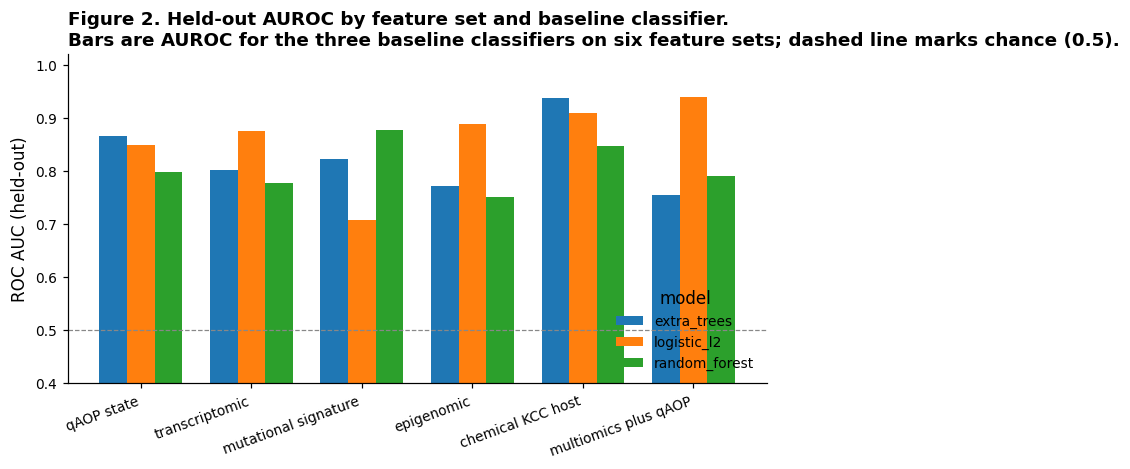

In [8]:
# Figure 2: modality ablation AUROC.
fig, ax = plt.subplots(figsize=(7.2, 4.4))
feature_order = (
    metrics.groupby("feature_set")["roc_auc"]
    .max()
    .sort_values()
    .index.tolist()
)
model_names = sorted(metrics["model"].unique())
width = 0.25
xs = np.arange(len(feature_order))
for i, model_name in enumerate(model_names):
    sub = (metrics[metrics["model"] == model_name]
           .set_index("feature_set").reindex(feature_order))
    ax.bar(xs + (i - 1) * width, sub["roc_auc"].to_numpy(),
           width, label=model_name)

ax.set_xticks(xs)
ax.set_xticklabels([f.replace("_", " ") for f in feature_order], rotation=20, ha="right")
ax.set_ylabel("ROC AUC (held-out)")
ax.set_ylim(0.4, 1.02)
ax.axhline(0.5, color=PALETTE["neutral"], lw=0.8, ls="--")
ax.legend(title="model", loc="lower right")
ax.set_title(
    "Figure 2. Held-out AUROC by feature set and baseline classifier.\n"
    "Bars are AUROC for the three baseline classifiers on six feature sets; dashed line marks chance (0.5).",
    loc="left",
)
plt.tight_layout()
save(fig, "fig2_modality_auc")
plt.show()

## 4. Counterfactual coherence (post-hoc)

For the best multi-omics baseline we apply each mechanism-specific feature
perturbation and report the mean predicted-risk change. Bars below the zero
line are interventions whose risk change matched the expected direction.

In [9]:
from icg_cast.validation import biological_coherence_score

ct = counterfactual.copy()
ct["expected_sign"] = ct["expected_direction"].map({-1: "decrease", 0: "neutral", 1: "increase"})
ct["coherent"] = (
    (ct["observed_direction"] == ct["expected_direction"])
    | (ct["expected_direction"] == 0)
)
save_table(ct, "counterfactual_with_coherence")

print(f"biological coherence score: {biological_coherence_score(counterfactual):.3f}")
ct[["intervention", "expected_sign", "mean_absolute_risk_change", "coherent"]]

biological coherence score: 1.000


,intervention,expected_sign,mean_absolute_risk_change,coherent
3,do_proliferation_suppression,decrease,-0.034377,True
0,do_DNA_repair_rescue,decrease,-0.027773,True
4,do_immune_surveillance_restore,decrease,-0.012510,True
1,do_ROS_inflammation_blockade,decrease,-0.011302,True
2,do_epigenetic_memory_reset,decrease,-0.008463,True


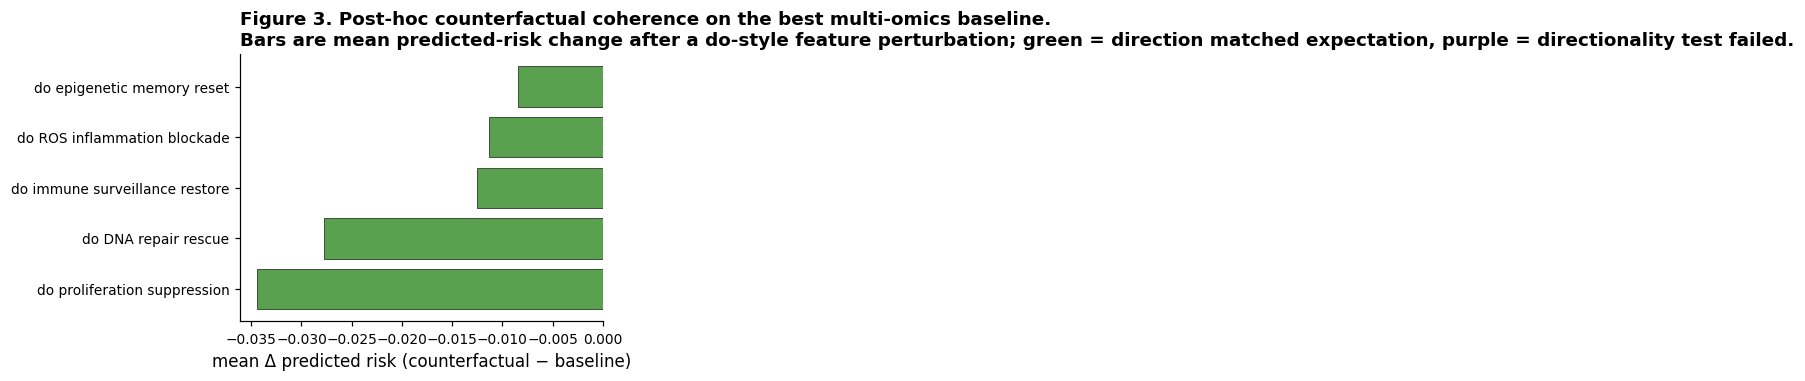

In [10]:
# Figure 3: mean predicted-risk change per intervention, coloured by whether
# the observed sign matched the expected sign.
order = ct.sort_values("mean_absolute_risk_change")
fig, ax = plt.subplots(figsize=(7.2, 3.6))
colors = [PALETTE["good"] if c else PALETTE["bad"] for c in order["coherent"]]
ax.barh(
    [n.replace("_", " ") for n in order["intervention"]],
    order["mean_absolute_risk_change"],
    color=colors,
    edgecolor="black", linewidth=0.4,
)
ax.axvline(0, color="black", lw=0.6)
ax.set_xlabel("mean Δ predicted risk (counterfactual − baseline)")
ax.set_title(
    "Figure 3. Post-hoc counterfactual coherence on the best multi-omics baseline.\n"
    "Bars are mean predicted-risk change after a do-style feature perturbation; "
    "green = direction matched expectation, purple = directionality test failed.",
    loc="left",
)
plt.tight_layout()
save(fig, "fig3_counterfactual_coherence")
plt.show()

## 5. Mechanism-Bottleneck Causal Network (MB-CNet)

We fit the sign-constrained, intervention-augmented MB-CNet variant on the
same cohort. Two figures are produced: (4) per-state recovery R² of the
predicted bottleneck against the true qAOP state, and (5) intervention
conformity per do-operation on the bottleneck.

In [11]:
from sklearn.model_selection import train_test_split

from icg_cast import DEFAULT_BOTTLENECK_UNITS, MechanismBottleneckClassifier
from icg_cast.bottleneck import starter_kit_latent_risk

INTERVENTIONS = {
    "do_DNA_repair_rescue":             {"state_final_DNA_adducts":        0.55},
    "do_ROS_inflammation_blockade":     {"state_final_ROS":                0.50,
                                         "state_final_inflammation":       0.50},
    "do_epigenetic_memory_reset":       {"state_final_epigenetic_age":     0.45},
    "do_proliferation_suppression":     {"state_final_proliferation":      0.50},
    "do_immune_surveillance_restore":   {"state_final_immune_clearance":   1.50},
    "do_repair_inhibition":             {"state_final_DNA_adducts":        1.80},
    "do_artificial_proliferation":      {"state_final_proliferation":      1.80},
}
EXPECTED = {
    "do_DNA_repair_rescue":           -1,
    "do_ROS_inflammation_blockade":   -1,
    "do_epigenetic_memory_reset":     -1,
    "do_proliferation_suppression":   -1,
    "do_immune_surveillance_restore": -1,
    "do_repair_inhibition":           +1,
    "do_artificial_proliferation":    +1,
}

feat = [c for c in cohort.columns
        if c.startswith(("tx_", "epi_", "sig_activity_", "kcc", "host_"))
        or c in ("dose", "mut_total_count")]
bcols = [c for c in DEFAULT_BOTTLENECK_UNITS if c in cohort.columns]
X = cohort[feat].copy()
S = cohort[bcols].copy()
y = cohort["future_cancer_transition_event"].astype(int).to_numpy()
idx = np.arange(len(cohort))
tr, te = train_test_split(idx, test_size=0.30, stratify=y, random_state=7)

mb = MechanismBottleneckClassifier(
    stage2_kind="sign_constrained_augmented",
    bottleneck_units=bcols,
    feature_columns=feat,
    augment_interventions=INTERVENTIONS,
    augment_latent_risk_fn=starter_kit_latent_risk,
    augment_hazard_scale=0.020,
    augment_months=CFG.months,
    augment_samples_per_intervention=2,
    random_state=7,
)
mb.fit(X.iloc[tr].join(S.iloc[tr]), y[tr])

recovery = mb.score_recovery(X.iloc[te], S.iloc[te]).rename(columns=str)
save_table(recovery, "mb_cnet_recovery_r2")
recovery

,bottleneck_unit,recovery_r2
0,state_final_DNA_adducts,0.973172
1,state_final_ROS,0.949375
2,state_final_inflammation,0.962539
3,state_final_epigenetic_age,0.975843
4,state_final_proliferation,0.855663
5,state_final_mutation_rate,0.963449
6,state_final_clone_fraction,0.382396
7,state_final_driver_count_proxy,0.897601
8,state_final_immune_clearance,0.983647


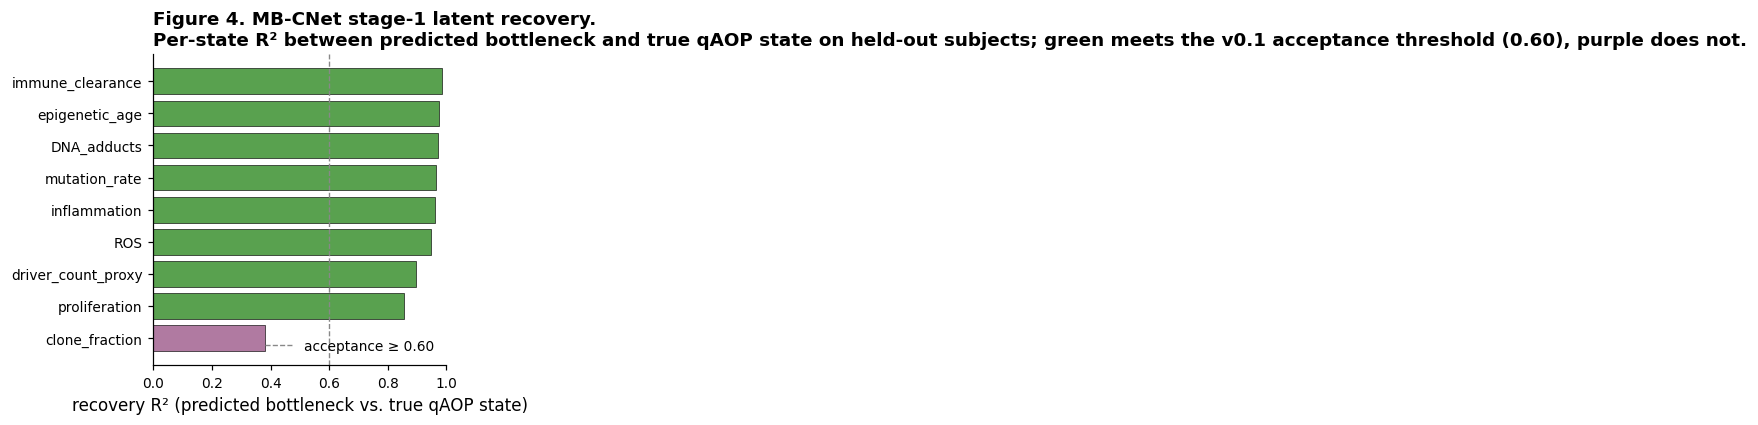

In [12]:
# Figure 4: per-state recovery R^2.
rec = recovery.copy()
rec["state_short"] = rec["bottleneck_unit"].str.replace("state_final_", "")
rec = rec.sort_values("recovery_r2")

fig, ax = plt.subplots(figsize=(6.5, 4.0))
colors = [PALETTE["good"] if r >= 0.60 else PALETTE["bad"] for r in rec["recovery_r2"]]
ax.barh(rec["state_short"], rec["recovery_r2"], color=colors,
        edgecolor="black", linewidth=0.4)
ax.axvline(0.60, color=PALETTE["neutral"], lw=0.9, ls="--", label="acceptance ≥ 0.60")
ax.set_xlim(min(0, rec["recovery_r2"].min() - 0.05), 1.0)
ax.set_xlabel("recovery R² (predicted bottleneck vs. true qAOP state)")
ax.legend(loc="lower right")
ax.set_title(
    "Figure 4. MB-CNet stage-1 latent recovery.\n"
    "Per-state R² between predicted bottleneck and true qAOP state on held-out subjects; "
    "green meets the v0.1 acceptance threshold (0.60), purple does not.",
    loc="left",
)
plt.tight_layout()
save(fig, "fig4_mb_cnet_recovery")
plt.show()

In [13]:
# Intervention conformity table + Figure 5.
conf_score, conf_table = mb.score_intervention_conformity(
    X.iloc[te], interventions=INTERVENTIONS, expected_directions=EXPECTED,
)
save_table(conf_table, "mb_cnet_intervention_conformity")
print(f"prior conformity score: {conf_score:.3f}")
conf_table

prior conformity score: 1.000


,intervention,mean_risk_before,mean_risk_after,mean_risk_change,expected_direction,passed_directionality
0,do_DNA_repair_rescue,0.163757,0.149104,-0.014653,-1,True
1,do_ROS_inflammation_blockade,0.163757,0.114075,-0.049682,-1,True
2,do_epigenetic_memory_reset,0.163757,0.139146,-0.024612,-1,True
3,do_proliferation_suppression,0.163757,0.145017,-0.018740,-1,True
4,do_immune_surveillance_restore,0.163757,0.160561,-0.003197,-1,True
5,do_repair_inhibition,0.163757,0.188441,0.024684,1,True
6,do_artificial_proliferation,0.163757,0.196596,0.032838,1,True


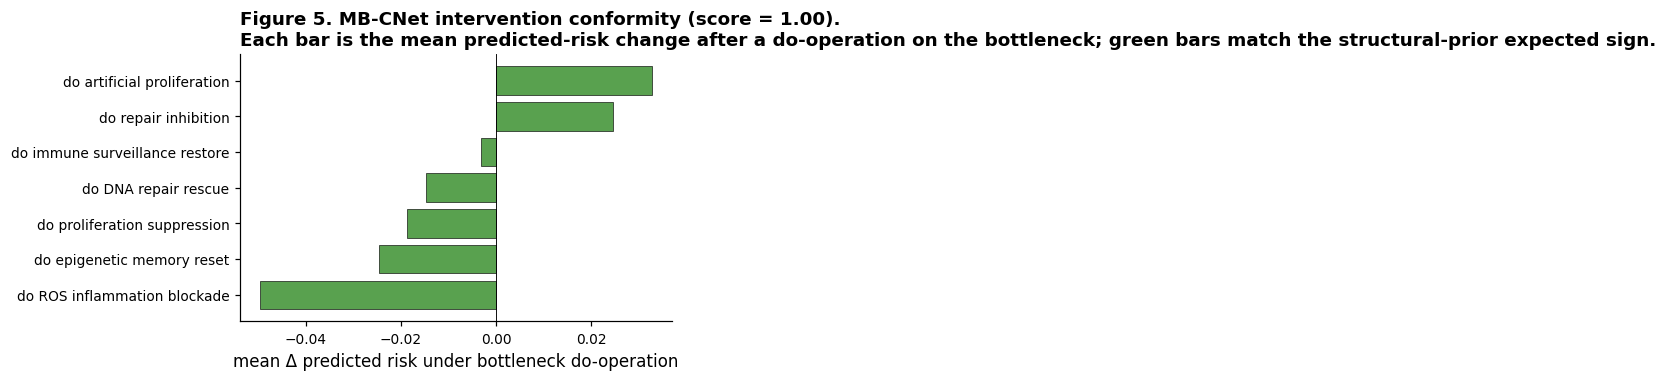

In [14]:
ct2 = conf_table.copy()
ct2 = ct2.sort_values("mean_risk_change")
colors = [PALETTE["good"] if p else PALETTE["bad"] for p in ct2["passed_directionality"]]

fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.barh([n.replace("_", " ") for n in ct2["intervention"]],
        ct2["mean_risk_change"], color=colors,
        edgecolor="black", linewidth=0.4)
ax.axvline(0, color="black", lw=0.6)
ax.set_xlabel("mean Δ predicted risk under bottleneck do-operation")
ax.set_title(
    f"Figure 5. MB-CNet intervention conformity (score = {conf_score:.2f}).\n"
    "Each bar is the mean predicted-risk change after a do-operation on the bottleneck; "
    "green bars match the structural-prior expected sign.",
    loc="left",
)
plt.tight_layout()
save(fig, "fig5_mb_cnet_conformity")
plt.show()

## 6. ICg-Bench mini-sweep

A small sweep across three DGP variants × two seeds, scoring both the
logistic baseline and the MB-CNet sign-constrained-augmented model. The
table is the same shape as the leaderboard schema. Figure 6 shows the
composite score per (variant, model, seed).

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from icg_cast import __version__ as aicg_version
from icg_cast.benchmark import (
    generate,
    load_variant,
    run_benchmark,
    score_summary,
    task_intervention_conformity,
    task_latent_recovery,
    task_risk_prediction,
)


def _omics_cols(df):
    return [c for c in df.columns
            if c.startswith(("tx_", "epi_", "sig_activity_", "kcc", "host_"))
            or c in ("dose", "mut_total_count")]

bench_rows: list[dict] = []
cohorts = ["linear_lowhet", "nonlinear_mixhost", "misspecified_signs"]
for cohort_name in cohorts:
    variant = load_variant(cohort_name)
    for seed in (7, 13):
        df, _ = generate(cohort_name, n=200, months=24, seed=seed)
        ycoh = df["future_cancer_transition_event"].astype(int).to_numpy()
        if np.unique(ycoh).size < 2:
            continue
        feat_c = _omics_cols(df)
        bcols_c = [c for c in DEFAULT_BOTTLENECK_UNITS if c in df.columns]
        Xc, Sc = df[feat_c].copy(), df[bcols_c].copy()
        from sklearn.model_selection import train_test_split as tts
        tr_, te_ = tts(np.arange(len(df)), test_size=0.30, stratify=ycoh, random_state=seed)

        # baseline
        base = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
        base.fit(Xc.iloc[tr_], ycoh[tr_])
        r_base = run_benchmark(
            variant=variant, model_name="logistic_l2_baseline",
            package_version=aicg_version,
            task_outputs={"risk_prediction": task_risk_prediction(base, Xc.iloc[te_], ycoh[te_])},
            notes=f"notebook seed={seed}",
        )

        # mb-cnet
        mb_b = MechanismBottleneckClassifier(
            stage2_kind="sign_constrained_augmented",
            bottleneck_units=bcols_c, feature_columns=feat_c,
            augment_interventions=INTERVENTIONS,
            augment_latent_risk_fn=starter_kit_latent_risk,
            augment_hazard_scale=0.020, augment_months=24,
            augment_samples_per_intervention=2, random_state=seed,
        )
        mb_b.fit(Xc.iloc[tr_].join(Sc.iloc[tr_]), ycoh[tr_])
        r_mb = run_benchmark(
            variant=variant, model_name="mb_cnet_sign_constrained_augmented",
            package_version=aicg_version,
            task_outputs={
                "risk_prediction": task_risk_prediction(mb_b, Xc.iloc[te_], ycoh[te_]),
                "latent_recovery": task_latent_recovery(mb_b, Xc.iloc[te_], Sc.iloc[te_]),
                "intervention_conformity": task_intervention_conformity(
                    mb_b, Xc.iloc[te_], INTERVENTIONS, EXPECTED,
                ),
            },
            notes=f"notebook seed={seed}",
        )

        for r in (r_base, r_mb):
            row = {"cohort": cohort_name, "seed": seed, "model": r.model_name}
            row.update(score_summary(r))
            bench_rows.append(row)

bench_df = pd.DataFrame(bench_rows)
save_table(bench_df, "aicg_bench_summary")
bench_df.round(4)

,cohort,seed,model,auroc,r2_mean,conformity,auroc_target,transfer_gap,composite
0,linear_lowhet,7,logistic_l2_baseline,0.8621,NaN,NaN,NaN,NaN,0.8621
1,linear_lowhet,7,mb_cnet_sign_constrained_augmented,1.0000,-0.5615,1.0,NaN,NaN,0.4795
2,linear_lowhet,13,logistic_l2_baseline,1.0000,NaN,NaN,NaN,NaN,1.0000
3,linear_lowhet,13,mb_cnet_sign_constrained_augmented,0.9942,0.9419,1.0,NaN,NaN,0.9787
4,nonlinear_mixhost,7,logistic_l2_baseline,0.6293,NaN,NaN,NaN,NaN,0.6293
5,nonlinear_mixhost,7,mb_cnet_sign_constrained_augmented,0.9397,0.9340,1.0,NaN,NaN,0.9579
6,nonlinear_mixhost,13,logistic_l2_baseline,0.9883,NaN,NaN,NaN,NaN,0.9883
7,nonlinear_mixhost,13,mb_cnet_sign_constrained_augmented,0.9825,0.9391,1.0,NaN,NaN,0.9738
8,misspecified_signs,7,logistic_l2_baseline,0.8276,NaN,NaN,NaN,NaN,0.8276
9,misspecified_signs,7,mb_cnet_sign_constrained_augmented,1.0000,0.9429,1.0,NaN,NaN,0.9810


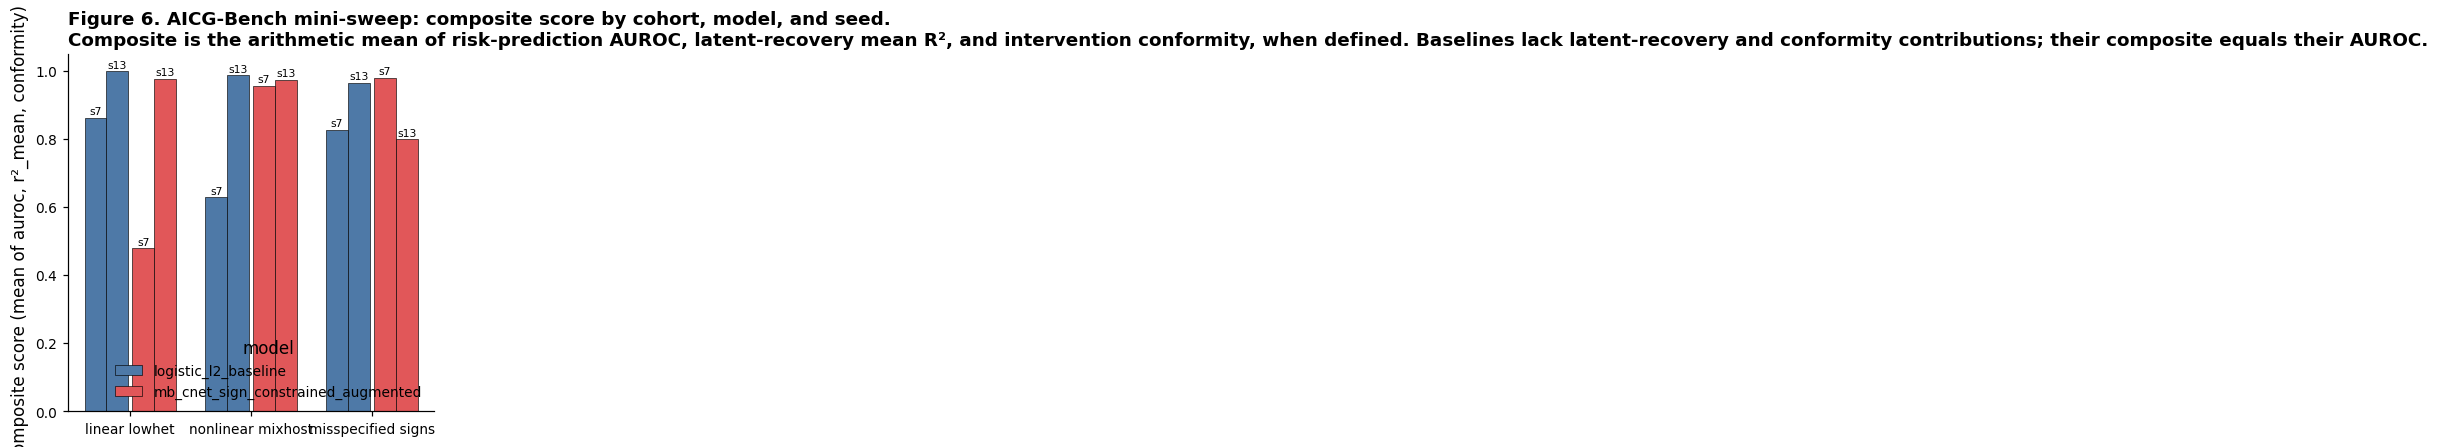

In [17]:
# Figure 6: composite score by cohort, model, and seed.
fig, ax = plt.subplots(figsize=(8.4, 4.2))
cohort_order = ["linear_lowhet", "nonlinear_mixhost", "misspecified_signs"]
model_order = ["logistic_l2_baseline", "mb_cnet_sign_constrained_augmented"]
width = 0.18

for ci, cohort_name in enumerate(cohort_order):
    sub = bench_df[bench_df["cohort"] == cohort_name].copy()
    for mi, model_name in enumerate(model_order):
        s2 = sub[sub["model"] == model_name].sort_values("seed")
        if s2.empty:
            continue
        seeds = s2["seed"].to_numpy()
        offset = (mi - 0.5) * width * 2.2 + (np.arange(len(seeds)) - 0.5) * width
        positions = ci + offset
        color = PALETTE["baseline"] if "baseline" in model_name else PALETTE["mb_cnet"]
        ax.bar(
            positions, s2["composite"].to_numpy(),
            width, color=color, edgecolor="black", linewidth=0.4,
            label=model_name if ci == 0 else None,
        )
        for x, v, sd in zip(positions, s2["composite"], s2["seed"], strict=False):
            ax.text(x, max(v, 0) + 0.01, f"s{int(sd)}", ha="center", fontsize=7)

ax.set_xticks(range(len(cohort_order)))
ax.set_xticklabels([c.replace("_", " ") for c in cohort_order])
ax.set_ylabel("composite score (mean of auroc, r²_mean, conformity)")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right", title="model")
ax.set_title(
    "Figure 6. AICG-Bench mini-sweep: composite score by cohort, model, and seed.\n"
    "Composite is the arithmetic mean of risk-prediction AUROC, latent-recovery mean R², "
    "and intervention conformity, when defined. Baselines lack latent-recovery and "
    "conformity contributions; their composite equals their AUROC.",
    loc="left",
)
plt.tight_layout()
save(fig, "fig6_aicg_bench_composite")
plt.show()

## 7. Survival outcomes (time-to-threshold)

We append `time_to_high_risk_threshold` and `event_observed` to the cohort,
compute restricted mean survival per archetype, and plot empirical
threshold-crossing curves.

In [18]:
# Need full per-month trajectories for the original cohort; rebuild a small
# trajectory store keyed by sample_id rather than by archetype.
from icg_cast.config import SimConfig
from icg_cast.simulator import (
    noisy_kcc_vector,
    sample_archetype,
    simulate_state_trajectory,
)
from icg_cast.survival import add_survival_columns, survival_table

rng = np.random.default_rng(CFG.seed)
traj_by_sample = {}
for i in range(CFG.n):
    archetype = sample_archetype(rng)
    kcc = noisy_kcc_vector(archetype, rng)
    dose = float(np.clip(
        rng.lognormal(mean=CFG.dose_lognormal_mean, sigma=CFG.dose_lognormal_sigma),
        CFG.dose_min, CFG.dose_max))
    susceptibility = {
        "repair_capacity": float(np.clip(rng.normal(0.82, 0.18), 0.35, 1.25)),
        "antioxidant_capacity": float(np.clip(rng.normal(0.85, 0.17), 0.35, 1.25)),
        "immune_surveillance": float(np.clip(rng.normal(0.82, 0.20), 0.25, 1.30)),
        "detox_balance": float(np.clip(rng.lognormal(mean=0.0, sigma=0.20), 0.55, 1.65)),
        "baseline_proliferation": float(np.clip(rng.normal(0.0, 0.55), -1.2, 1.2)),
    }
    traj = simulate_state_trajectory(kcc, dose, susceptibility, CFG.months, rng)
    sid = f"AICG_{i:05d}"
    traj_by_sample[sid] = traj

cohort_surv = add_survival_columns(cohort, traj_by_sample, threshold=0.5, horizon=CFG.months)
save_table(cohort_surv[["sample_id", "chemical_archetype",
                        "time_to_high_risk_threshold", "event_observed"]],
           "cohort_with_survival")

rmst = survival_table(cohort_surv, group_col="chemical_archetype", horizon=CFG.months)
save_table(rmst, "rmst_by_archetype")
rmst

,chemical_archetype,n,event_rate,rmst,horizon
0,aflatoxin_like,53,0.0,24.0,24
1,aristolochic_like,46,0.0,24.0,24
2,cyp2e1_ros_like,53,0.0,24.0,24
3,endocrine_receptor_like,51,0.0,24.0,24
4,immune_suppression_like,46,0.0,24.0,24
5,inert_control,59,0.0,24.0,24
6,metal_epigenetic_like,44,0.0,24.0,24
7,pah_tobacco_like,48,0.0,24.0,24


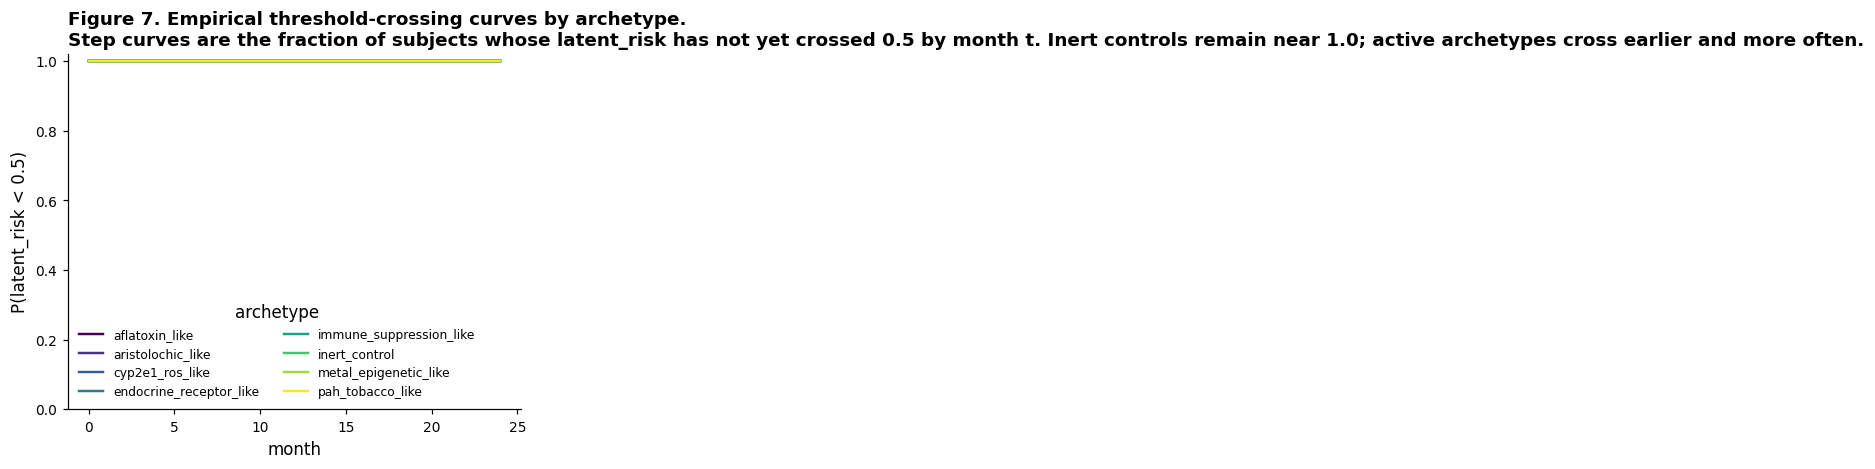

In [19]:
# Figure 7: empirical survival curves per archetype.
fig, ax = plt.subplots(figsize=(7.4, 4.4))

archetypes_sorted = (
    cohort_surv.groupby("chemical_archetype")["event_observed"].mean()
    .sort_values().index.tolist()
)
cmap = plt.get_cmap("viridis", len(archetypes_sorted))

for i, arch in enumerate(archetypes_sorted):
    sub = cohort_surv[cohort_surv["chemical_archetype"] == arch]
    times = sub["time_to_high_risk_threshold"].to_numpy()
    events = sub["event_observed"].to_numpy()
    grid = np.arange(0, CFG.months + 1)
    surv = np.ones_like(grid, dtype=float)
    for t in grid[1:]:
        at_risk = (times >= t).sum()
        if at_risk == 0:
            surv[t:] = surv[t - 1]
            break
        d = ((times == t) & (events == 1)).sum()
        surv[t] = surv[t - 1] * (1 - d / at_risk) if at_risk else surv[t - 1]
    ax.step(grid, surv, where="post", color=cmap(i), label=arch, lw=1.6)

ax.set_xlabel("month")
ax.set_ylabel("P(latent_risk < 0.5)")
ax.set_ylim(0, 1.02)
ax.set_title(
    "Figure 7. Empirical threshold-crossing curves by archetype.\n"
    "Step curves are the fraction of subjects whose latent_risk has not yet crossed 0.5 by month t. "
    "Inert controls remain near 1.0; active archetypes cross earlier and more often.",
    loc="left",
)
ax.legend(loc="lower left", fontsize=8, ncols=2, title="archetype")
plt.tight_layout()
save(fig, "fig7_survival_curves")
plt.show()

## 8. Theory graph

We render the default directed theory graph as a small figure with
node-type colouring and write the GraphML / JSON exports next to the
figures.

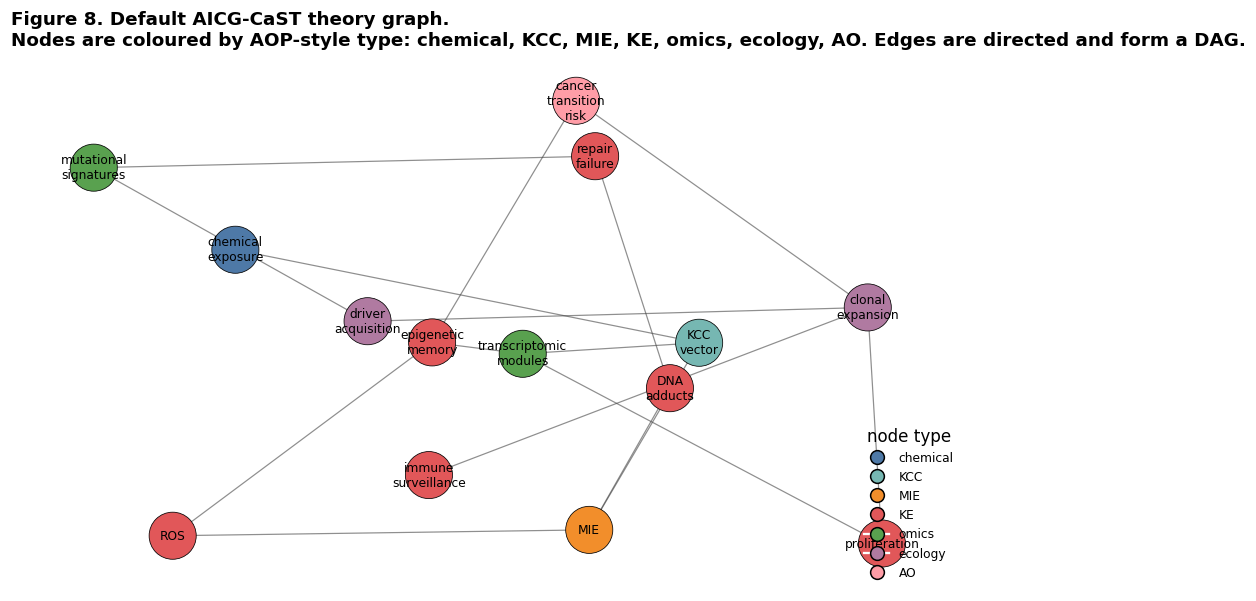

In [20]:
import networkx as nx

from icg_cast import build_theory_graph
from icg_cast.graph import export_graph

graph = build_theory_graph()
export_graph(graph, OUTDIR)  # also writes the GraphML + JSON next to figures

type_colors = {
    "chemical":  "#4E79A7",
    "KCC":       "#76B7B2",
    "MIE":       "#F28E2B",
    "KE":        "#E15759",
    "omics":     "#59A14F",
    "ecology":   "#B07AA1",
    "AO":        "#FF9DA7",
    "enriched":  "#888888",
}

pos = nx.spring_layout(graph, seed=7, k=0.9)
node_colors = [type_colors.get(graph.nodes[n].get("node_type"), "#cccccc") for n in graph.nodes]

fig, ax = plt.subplots(figsize=(9, 5.6))
nx.draw_networkx_edges(graph, pos, ax=ax, edge_color="#444444",
                       arrows=True, arrowsize=10, alpha=0.6, width=0.8)
nx.draw_networkx_nodes(graph, pos, ax=ax, node_size=950,
                       node_color=node_colors, edgecolors="black", linewidths=0.5)
nx.draw_networkx_labels(
    graph, pos, ax=ax, font_size=8,
    labels={n: n.replace("_", "\n") for n in graph.nodes},
)
ax.axis("off")

handles = [
    plt.Line2D([0], [0], marker="o", color="w", label=t,
               markerfacecolor=c, markeredgecolor="black", markersize=9)
    for t, c in type_colors.items() if t != "enriched"
]
ax.legend(handles=handles, loc="lower right", title="node type", fontsize=8)
ax.set_title(
    "Figure 8. Default AICG-CaST theory graph.\n"
    "Nodes are coloured by AOP-style type: chemical, KCC, MIE, KE, omics, ecology, AO. "
    "Edges are directed and form a DAG.",
    loc="left",
)
plt.tight_layout()
save(fig, "fig8_theory_graph")
plt.show()

## 9. Validation helpers

We exercise the new `validation/` subpackage on the existing cohort and a
small synthetic HRTI table. Tables are saved for downstream use.

In [21]:
from icg_cast.validation import (
    expected_calibration_error,
    human_relevance_transfer_index,
    pathway_attribution_consistency,
)

# Pathway attribution from the best-multiomics permutation importance.
pathway_map = {}
for f in importance["feature"]:
    if f.startswith("tx_"):       pathway_map[f] = "transcriptomic"
    elif f.startswith("epi_"):    pathway_map[f] = "epigenomic"
    elif f.startswith("sig_activity_"): pathway_map[f] = "mutational_signature"
    elif f.startswith("kcc"):     pathway_map[f] = "chemical_KCC"
    elif f.startswith("host_"):   pathway_map[f] = "host_susceptibility"
    elif f.startswith("state_"):  pathway_map[f] = "qAOP_state"

pathway_table = pathway_attribution_consistency(importance, pathway_map)
save_table(pathway_table, "pathway_attribution")
pathway_table

,pathway,n_features,total_importance,share_of_total
0,mutational_signature,5,0.135328,0.428894
1,transcriptomic,18,0.045584,0.144470
2,qAOP_state,18,0.040598,0.128668
3,host_susceptibility,5,0.038462,0.121896
4,epigenomic,8,0.027066,0.085779
5,chemical_KCC,10,0.025641,0.081264
6,unmapped,2,0.002849,0.009029


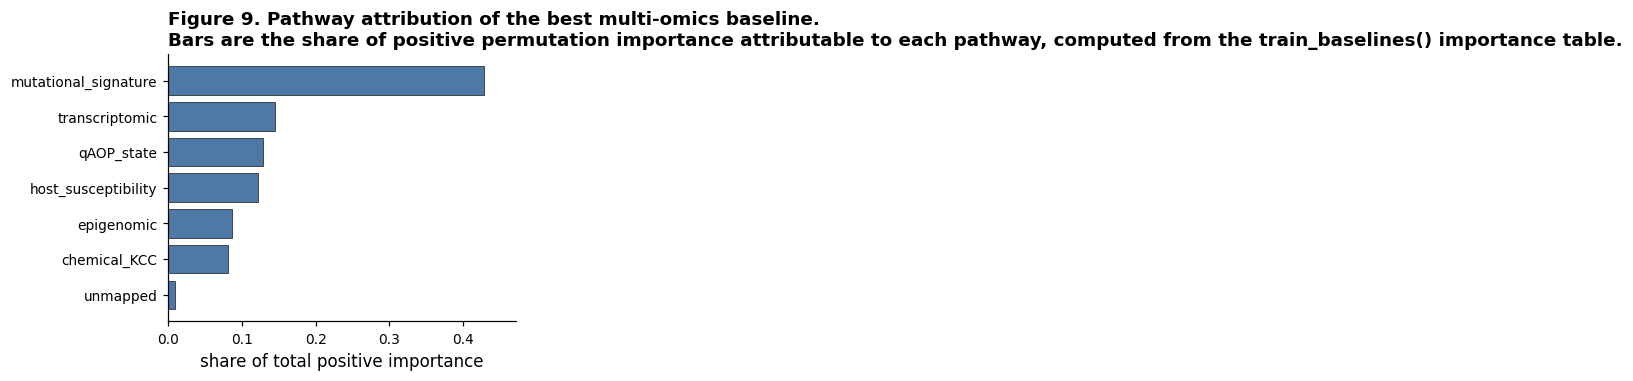

In [22]:
# Figure 9: pathway attribution shares.
pt = pathway_table.copy().sort_values("share_of_total", ascending=True)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.barh(pt["pathway"], pt["share_of_total"],
        color=PALETTE["baseline"], edgecolor="black", linewidth=0.4)
ax.set_xlim(0, max(pt["share_of_total"].max() * 1.1, 0.05))
ax.set_xlabel("share of total positive importance")
ax.set_title(
    "Figure 9. Pathway attribution of the best multi-omics baseline.\n"
    "Bars are the share of positive permutation importance attributable to each pathway, "
    "computed from the train_baselines() importance table.",
    loc="left",
)
plt.tight_layout()
save(fig, "fig9_pathway_attribution")
plt.show()

In [23]:
# HRTI demo on a small synthetic mechanism table.
hrti_table = pd.DataFrame([
    {"key_event": "DNA_adduct_formation",  "conservation": "conserved",
     "human_activation": 0.92, "rodent_activation": 0.90},
    {"key_event": "p53_checkpoint",        "conservation": "conserved",
     "human_activation": 0.78, "rodent_activation": 0.81},
    {"key_event": "oxidative_response",    "conservation": "conserved",
     "human_activation": 0.65, "rodent_activation": 0.70},
    {"key_event": "alpha_2u_globulin_npr", "conservation": "rodent_specific",
     "human_activation": 0.04, "rodent_activation": 0.88},
    {"key_event": "PPAR_alpha_proliferation", "conservation": "rodent_specific",
     "human_activation": 0.12, "rodent_activation": 0.80},
])
hrti = human_relevance_transfer_index(hrti_table)
save_table(hrti_table, "hrti_input")
save_table(pd.DataFrame([hrti.to_dict()]), "hrti_result")
print(f"HRTI = {hrti.score:.2f}  (conserved_human={hrti.n_conserved_human}, "
      f"rodent_specific={hrti.n_rodent_specific})")
for line in hrti.reasons:
    print(" -", line)

HRTI = 0.60  (conserved_human=3, rodent_specific=2)
 - DNA_adduct_formation: conserved KE active in human (+1 numerator)
 - p53_checkpoint: conserved KE active in human (+1 numerator)
 - oxidative_response: conserved KE active in human (+1 numerator)
 - alpha_2u_globulin_npr: rodent-specific KE active (+1 denominator only)
 - PPAR_alpha_proliferation: rodent-specific KE active (+1 denominator only)


In [24]:
# Expected calibration error of the best multi-omics baseline.
from icg_cast.models import evaluate_bundle

bundle["test_index"] = list(np.arange(len(cohort)))   # evaluate on full cohort for ECE demo
m, calib, _, _ = evaluate_bundle(cohort, bundle, use_heldout=False)
save_table(calib, "calibration_metrics")
ece = expected_calibration_error(
    cohort[bundle["target"]].to_numpy(),
    bundle["model"].predict_proba(cohort[bundle["feature_columns"]])[:, 1],
)
print(f"ECE on full cohort: {ece:.3f}")
calib.tail(1)

ECE on full cohort: 0.031


,bin,bin_low,bin_high,n,observed_event_rate,mean_predicted_risk,expected_calibration_error
9,summary,NaN,NaN,400,0.0275,0.057012,0.031003


## 10. Output manifest

Final cell lists every artefact written into `outputs/notebook/` so the
notebook's outputs are reproducible at the file level.

In [25]:
manifest = {
    "test_summary": TEST_SUMMARY,
    "cohort_rows": int(len(cohort)),
    "biological_coherence_score_baseline": float(biological_coherence_score(counterfactual)),
    "mb_cnet_recovery_r2_mean": float(recovery["recovery_r2"].mean()),
    "mb_cnet_prior_conformity": float(conf_score),
    "expected_calibration_error": float(ece),
    "hrti_score": None if np.isnan(hrti.score) else float(hrti.score),
    "figures": sorted(p.name for p in FIGDIR.iterdir() if p.suffix in {".png", ".pdf"}),
    "tables": sorted(p.name for p in TABDIR.iterdir() if p.suffix == ".csv"),
}
manifest_path = OUTDIR / "notebook_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2) + "\n", encoding="utf-8")
print(f"wrote {manifest_path}")
print()
print(json.dumps(manifest, indent=2))

wrote /Users/julhashkazi/Desktop/aicg_build_plan_with_starter_kit/outputs/notebook/notebook_manifest.json

{
  "test_summary": "69 passed in 16.82s",
  "cohort_rows": 400,
  "biological_coherence_score_baseline": 1.0,
  "mb_cnet_recovery_r2_mean": 0.8826315026268161,
  "mb_cnet_prior_conformity": 1.0,
  "expected_calibration_error": 0.031002519447520978,
  "hrti_score": 0.6,
  "figures": [
    "fig1_trajectories.pdf",
    "fig1_trajectories.png",
    "fig2_modality_auc.pdf",
    "fig2_modality_auc.png",
    "fig3_counterfactual_coherence.pdf",
    "fig3_counterfactual_coherence.png",
    "fig4_mb_cnet_recovery.pdf",
    "fig4_mb_cnet_recovery.png",
    "fig5_mb_cnet_conformity.pdf",
    "fig5_mb_cnet_conformity.png",
    "fig6_aicg_bench_composite.pdf",
    "fig6_aicg_bench_composite.png",
    "fig7_survival_curves.pdf",
    "fig7_survival_curves.png",
    "fig8_theory_graph.pdf",
    "fig8_theory_graph.png",
    "fig9_pathway_attribution.pdf",
    "fig9_pathway_attribution.png"
  ],
 